# Linear Regression from Scratch to Scikit-Learn
This notebook demonstrates how to build a Multiple Linear Regression model manually using NumPy and then compares it with the standard `scikit-learn` implementation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

## 1. Data Preparation
We define our features (X) like experience and GPA, and our target variable (y) which is Salary. We'll visualize these relationships to see if they look linear.

In [2]:
X = np.array(
    [
        [1, 4, 1.5, 3.8],
        [3, 6, 1.0, 3.1],
        [4, 7, 0.8, 3.9],
        [5, 8, 0.4, 3.4],
        [7, 9, 0.2, 2.8],
    ]
)

# w =[5,10,-2,0.5] , b=2.0
y = np.array([45.9, 76.55, 92.35, 107.9, 128.0])

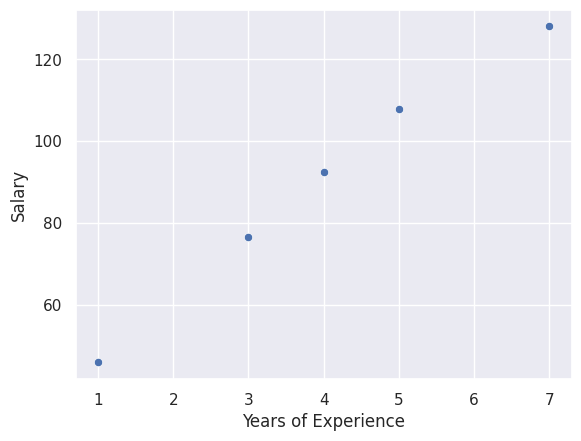

In [3]:
# Visualize the relationship between experience and salary
sns.scatterplot(x=X[:, 0:1].ravel(), y=y)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

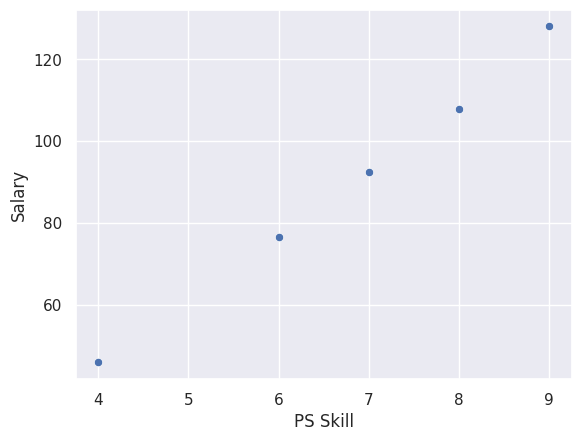

In [4]:
sns.scatterplot(x=X[:, 1:2].ravel(), y=y)
plt.xlabel("PS Skill")
plt.ylabel("Salary")
plt.show()

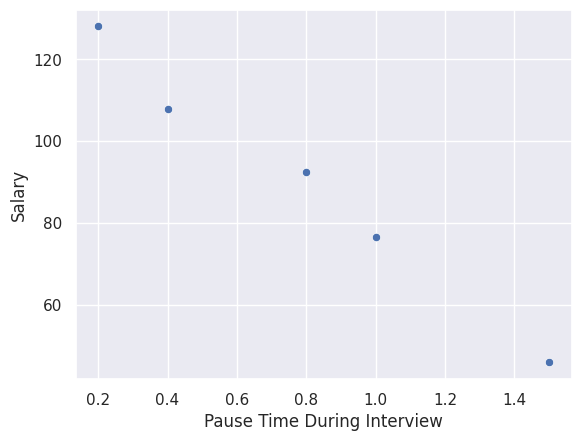

In [5]:
sns.scatterplot(x=X[:, 2:3].ravel(), y=y)
plt.xlabel("Pause Time During Interview")
plt.ylabel("Salary")
plt.show()

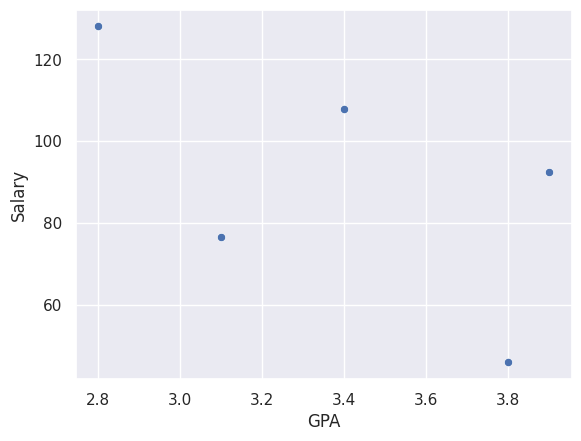

In [6]:
sns.scatterplot(x=X[:, 3:].ravel(), y=y)
plt.xlabel("GPA")
plt.ylabel("Salary")
plt.show()

## 2. Manual Implementation
To understand how the model 'learns', we define three key components:
1. **Prediction Function**: Calculates $f(x) = w_1x_1 + ... + w_nx_n + b$
2. **Cost Function**: Measures how far off our predictions are (Mean Squared Error).
3. **Gradient Descent**: The optimizer that adjusts weights ($w$) and bias ($b$) to minimize the cost.

In [7]:
def make_prediction(X, W, b):
    """Calculates the model output: f(x) = wx + b"""
    m = X.shape[0]  # Number of training examples
    pred_list = np.zeros((m,))  # Initialize an array to store results

    for i in range(m):
        # X[i] = feature vector , W = weights_vector
        pred_list[i] = np.dot(W, X[i]) + b

    return pred_list

In [8]:
m = X.shape[0]
n = X.shape[1]

W_init = np.ones((n,))
b_init = 1.0

make_prediction(X, W_init, b_init)

array([11.3, 14.1, 16.7, 17.8, 20. ])

In [9]:
def compute_cost(X, y, W, b):
    """Calculates the Mean Squared Error (MSE) to measure model accuracy"""
    m = X.shape[0]
    cost = 0.0

    pred_list = make_prediction(X, W, b)

    # print(pred_list)

    error = pred_list - y
    # print(error)
    error_squared = error**2
    # print(error_squared)
    cost = np.sum(error_squared)

    # We divide by 2m for mathematical convenience in gradient calculations
    cost = cost / (2 * m)

    return cost

In [10]:
W_init = np.ones((n,))
b_init = 1.0
compute_cost(X, y, W_init, b_init)

np.float64(3060.2095)

In [11]:
def calculate_gradient(X, y, W, b):
    """Computes the gradient (direction to move) for w and b"""
    m = X.shape[0]
    n = X.shape[1]

    dj_dw = np.zeros((n,))  ## jotota feature totota weights
    dj_db = 0.0  # Change needed for bias

    for i in range(m):
        prediction = np.dot(W, X[i]) + b
        error = prediction - y[i]
        dj_db = dj_db + error

        for j in range(n):
            dj_dw[j] = dj_dw[j] + (error * X[i, j])

    return dj_dw / m, dj_db / m

In [12]:
W_init = np.ones((n,))
b_init = 1.0
calculate_gradient(X, y, W_init, b_init)

(array([-346.21 , -547.09 ,  -46.502, -245.77 ]), np.float64(-74.16))

In [13]:
def gradient_descent(X, y, w_input, b_input, max_iter, alpha=0.01):
    """Automates the tuning of w and b to minimize cost"""
    w = w_input
    b = b_input
    cost_memo = []
    iteration = []

    for i in range(max_iter):
        # 1. Calculate the gradients (the slope)
        dj_dw, dj_db = calculate_gradient(X, y, w, b)

        # 2. Update parameters by taking a small step (alpha) against the gradient

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        # 3. Track progress by saving the cost
        cost = compute_cost(X, y, w, b)
        cost_memo.append(cost)
        iteration.append(i)

        # Log the status every 100 steps
        if i % 100 == 0:
            print(
                f"Iteration {i}: Cost {cost:0.4f},dj_dw: {dj_dw} ,dj_db : {dj_db} w: {w}, b: {b:0.4f}"
            )

    return w, b, cost_memo, iteration

### Training the Model
We initialize our weights to zero and run the gradient descent loop for many iterations to find the optimal values.

In [14]:
W_init = np.zeros((n,))
b_init = 0.0

w_final, b_final, cost_memo, iter_list = gradient_descent(
    X, y, w_input=W_init, b_input=b_init, max_iter=100000, alpha=0.01
)

Iteration 0: Cost 188.4458,dj_dw: [-416.09  -660.91   -57.608 -299.43 ] ,dj_db : -90.14 w: [4.1609  6.6091  0.57608 2.9943 ], b: 0.9014
Iteration 100: Cost 0.1977,dj_dw: [-0.28972633 -0.05290958  0.24653403  0.43027154] ,dj_db : 0.08612436152810546 w: [ 6.8215041   8.3071171  -0.38008643  1.775159  ], b: 0.7104
Iteration 200: Cost 0.1303,dj_dw: [ 0.02982799 -0.05138487  0.04097921  0.06083368] ,dj_db : 0.007027042739051126 w: [ 6.88604616  8.35924356 -0.48209566  1.60468101], b: 0.6799
Iteration 300: Cost 0.1229,dj_dw: [ 0.05097646 -0.04994653  0.0258774   0.03389236] ,dj_db : 0.001434162447482379 w: [ 6.84103994  8.40989801 -0.51257454  1.56262078], b: 0.6769
Iteration 400: Cost 0.1162,dj_dw: [ 0.05111217 -0.04855146  0.02422668  0.0311383 ] ,dj_db : 0.0010265453320016603 w: [ 6.7896808   8.45913669 -0.53741432  1.53048588], b: 0.6757
Iteration 500: Cost 0.1098,dj_dw: [ 0.04980317 -0.04719556  0.0235398   0.03011513] ,dj_db : 0.0009845325017138861 w: [ 6.7392106   8.50700022 -0.561278

In [15]:
print(w_final)
print(b_final)

# w =[5,10,-2,0.5] , b=2.0

[ 4.9736024  10.14304775 -1.56445471  0.47744225]
0.8695947679498179


### Making Predictions
Now that we have trained weights, we can predict the salary for a new person given their features.

In [16]:
X_test = [2, 10, 1.5, 3.8]

prediction_of_new_data = (
    w_final[0] * X_test[0]
    + w_final[1] * X_test[1]
    + w_final[2] * X_test[2]
    + w_final[3] * X_test[3]
    + b_final
)

print(prediction_of_new_data)

111.71487549666952


# Linear Regression using scikit learn

Using libraries like `scikit-learn` is the industry standard. It's much faster and handles the math automatically.

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor

In [18]:
model1 = LinearRegression()

# learning
model1.fit(X, y)

weights = model1.coef_
bias = model1.intercept_

print(weights)
print(bias)

[ 5.  10.  -2.   0.5]
2.000000000000142


### SGD regressor


The `SGDRegressor` implements Stochastic Gradient Descent. It's particularly useful for very large datasets where the standard `LinearRegression` might be too slow.

In [19]:
model2 = SGDRegressor(penalty=None, max_iter=10000000, learning_rate="constant")

model2.fit(X, y)


weights = model2.coef_
bias = model2.intercept_

print(weights)
print(bias)

[ 6.886112    8.21157918 -0.6030496   1.76499363]
[0.59682259]
